Assisted with google gemini

In [1]:
!pip install torch
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 18.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager
from google.colab import drive
from sklearn.model_selection import train_test_split
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def feature_engineering(data):
    data['is_female'] = (data['gender'] == 'Female').astype(int)
    X = data[['is_female', 'age', 'weight', 'height']].values.astype(np.float32)
    Y = data['total_lift'].values.astype(np.float32) # Cast Y to float32
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    X_train_tensor = torch.from_numpy(X_train)
    y_train_tensor = torch.from_numpy(y_train)
    X_test_tensor = torch.from_numpy(X_test)
    y_test_tensor = torch.from_numpy(y_test)
    INPUT_SIZE = X_train_tensor.shape[1]
    OUTPUT_SIZE = 1
    BATCH_SIZE = 32
    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    return data_loader, INPUT_SIZE, OUTPUT_SIZE, X_test_tensor, y_test_tensor # Return test tensors

In [7]:
class SimpleNNRegressor(nn.Module):
    """A simple 2-layer Feedforward Neural Network for regression."""
    def __init__(self, input_size, output_size):
        super(SimpleNNRegressor, self).__init__()
        self.layer1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(128, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [5]:
# --- Training Function for Standard SGD ---
def train_standard(model, data_loader, criterion, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    epoch_losses = [] # List to store average loss for each epoch

    print("\n--- Starting Standard SGD Regression Training ---")
    for epoch in range(1, epochs + 1):
        total_loss = 0
        for data, target in data_loader:
            data, target = data.to(device), target.to(device).float() # Cast target to float
            target = target.unsqueeze(1) # Add an extra dimension to target

            # 1. Forward pass
            output = model(data)
            loss = criterion(output, target)

            # 2. Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(data_loader)
        epoch_losses.append(avg_loss) # Store the average loss
        # Reporting MSE Loss
        print(f"Standard Epoch {epoch}/{epochs}, MSE Loss: {avg_loss:.4f}")

    return epoch_losses # Return the list of losses

In [4]:
data = pd.read_csv('/content/athletes_v2.csv')

In [7]:
data_loader, INPUT_SIZE, OUTPUT_SIZE, X_test_tensor, y_test_tensor = feature_engineering(data) # Capture test tensors
# --- Instantiate and Train Standard Model ---
model_standard = SimpleNNRegressor(INPUT_SIZE, OUTPUT_SIZE)
optimizer_standard = optim.SGD(model_standard.parameters(), lr=0.0001) # Reduced learning rate
# Use Mean Squared Error for regression
criterion = nn.MSELoss()

In [8]:
standard_losses = train_standard(model_standard, data_loader, criterion, optimizer_standard, 50)


--- Starting Standard SGD Regression Training ---
Standard Epoch 1/50, MSE Loss: 425265962.2845
Standard Epoch 2/50, MSE Loss: 1137080.3056
Standard Epoch 3/50, MSE Loss: 862020.5301
Standard Epoch 4/50, MSE Loss: 7356232.9789
Standard Epoch 5/50, MSE Loss: 528994.1486
Standard Epoch 6/50, MSE Loss: 415521.9925
Standard Epoch 7/50, MSE Loss: 325349.5893
Standard Epoch 8/50, MSE Loss: 260921.4646
Standard Epoch 9/50, MSE Loss: 213260.7921
Standard Epoch 10/50, MSE Loss: 177932.0496
Standard Epoch 11/50, MSE Loss: 151781.4271
Standard Epoch 12/50, MSE Loss: 132431.0932
Standard Epoch 13/50, MSE Loss: 118092.3739
Standard Epoch 14/50, MSE Loss: 107464.2843
Standard Epoch 15/50, MSE Loss: 99588.3434
Standard Epoch 16/50, MSE Loss: 93772.7596
Standard Epoch 17/50, MSE Loss: 89457.4087
Standard Epoch 18/50, MSE Loss: 86278.4797
Standard Epoch 19/50, MSE Loss: 83924.3401
Standard Epoch 20/50, MSE Loss: 82176.8173
Standard Epoch 21/50, MSE Loss: 80878.0017
Standard Epoch 22/50, MSE Loss: 7991

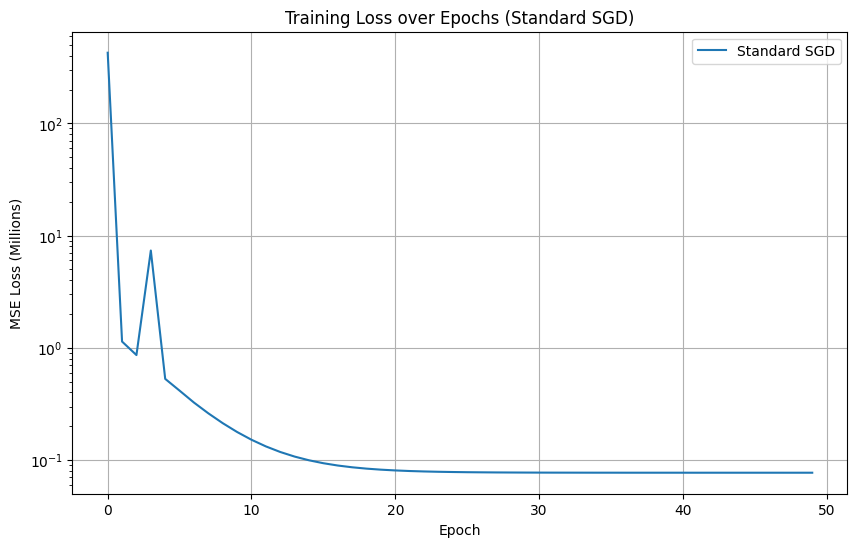

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(standard_losses, label='Standard SGD')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Epochs (Standard SGD)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# --- Evaluate the Standard Model on the Test Set ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_standard.to(device)
model_standard.eval() # Set the model to evaluation mode

# Assuming X_test_tensor and y_test_tensor are available from feature_engineering
# If not, you would need to make them accessible (e.g., return them from feature_engineering)

# Move test data to the device
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device).float()
y_test_tensor = y_test_tensor.unsqueeze(1) # Ensure target shape matches output shape

with torch.no_grad(): # Disable gradient calculation for evaluation
    predictions = model_standard(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)

print(f"\n--- Standard Model Test Set Evaluation ---")
print(f"MSE Loss on Test Set: {test_loss.item():.4f}")


--- Standard Model Test Set Evaluation ---
MSE Loss on Test Set: 76812.7812


With DP

In [5]:
# --- Differential Privacy Parameters (Same as before) ---
DELTA = 1e-5
NOISE_MULTIPLIER = 1.0
MAX_GRAD_NORM = 1.0
VIRTUAL_BATCH_SIZE = 4

In [28]:
# --- Training Function for DP-SGD ---
def train_dp(model, data_loader, criterion, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()
    ALPHAS = [1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0,
          9.0, 10.0, 12.0, 14.0, 16.0, 20.0, 24.0, 28.0, 32.0, 36.0, 40.0, 48.0, 64.0]

    # 1. Instantiate PrivacyEngine
    privacy_engine = PrivacyEngine(accountant="rdp")

    # 2. Wrap model, optimizer, and data_loader with PrivacyEngine
    model_dp, optimizer_dp, data_loader_dp = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=data_loader,
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    print("\n--- Starting DP-SGD Regression Training ---")

    epoch_losses = [] # List to store average loss for each epoch

    # 3. Use BatchMemoryManager for virtual batching
    with BatchMemoryManager(
        data_loader=data_loader_dp,
        max_physical_batch_size=VIRTUAL_BATCH_SIZE,
        optimizer=optimizer_dp
    ) as memory_safe_data_loader:

        for epoch in range(1, epochs + 1):
            total_loss = 0
            for data, target in memory_safe_data_loader:
                data, target = data.to(device), target.to(device)
                target = target.unsqueeze(1) # Add an extra dimension to target

                # Forward pass
                output = model_dp(data)
                loss = criterion(output, target)

                # Backward and optimize (handles clipping and noise)
                optimizer_dp.zero_grad()
                loss.backward()
                optimizer_dp.step()

                total_loss += loss.item()

            # Track privacy expenditure
            epsilon, best_alpha = privacy_engine.accountant.get_privacy_spent(
            # Positional Arg 1: ALPHAS
                alphas=ALPHAS,
                # Positional Arg 2: DELTA
                delta=DELTA
            )
            avg_loss = total_loss / len(data_loader_dp)
            epoch_losses.append(avg_loss) # Store the average loss

            print(
                f"DP-SGD Epoch {epoch}/{epochs}, "
                f"MSE Loss: {avg_loss:.4f}, "
                f"Privacy Budget: (ε={epsilon:.2f}, δ={DELTA})"
            )

    return epoch_losses # Return the list of losses

In [29]:
data_loader, INPUT_SIZE, OUTPUT_SIZE, X_test_tensor, y_test_tensor = feature_engineering(data)
# --- Instantiate and Train DP-SGD Model ---
model_dp = SimpleNNRegressor(INPUT_SIZE, OUTPUT_SIZE)
optimizer_dp = optim.SGD(model_dp.parameters(), lr=0.0001)
criterion = nn.MSELoss()

In [30]:
dp_losses = train_dp(model_dp, data_loader, criterion, optimizer_dp, 50)

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Starting DP-SGD Regression Training ---
DP-SGD Epoch 1/50, MSE Loss: 8902972.0000, Privacy Budget: (ε=0.75, δ=1e-05)
DP-SGD Epoch 2/50, MSE Loss: 8284016.1289, Privacy Budget: (ε=0.76, δ=1e-05)
DP-SGD Epoch 3/50, MSE Loss: 7769047.3966, Privacy Budget: (ε=0.78, δ=1e-05)
DP-SGD Epoch 4/50, MSE Loss: 7235811.4324, Privacy Budget: (ε=0.79, δ=1e-05)
DP-SGD Epoch 5/50, MSE Loss: 6773053.4953, Privacy Budget: (ε=0.81, δ=1e-05)
DP-SGD Epoch 6/50, MSE Loss: 6307296.3534, Privacy Budget: (ε=0.82, δ=1e-05)
DP-SGD Epoch 7/50, MSE Loss: 5687494.6677, Privacy Budget: (ε=0.83, δ=1e-05)
DP-SGD Epoch 8/50, MSE Loss: 5350658.9428, Privacy Budget: (ε=0.85, δ=1e-05)
DP-SGD Epoch 9/50, MSE Loss: 4888123.2079, Privacy Budget: (ε=0.86, δ=1e-05)
DP-SGD Epoch 10/50, MSE Loss: 4476579.3578, Privacy Budget: (ε=0.88, δ=1e-05)
DP-SGD Epoch 11/50, MSE Loss: 4046782.0948, Privacy Budget: (ε=0.89, δ=1e-05)
DP-SGD Epoch 12/50, MSE Loss: 3585954.6704, Privacy Budget: (ε=0.91, δ=1e-05)
DP-SGD Epoch 13/50, MSE Loss

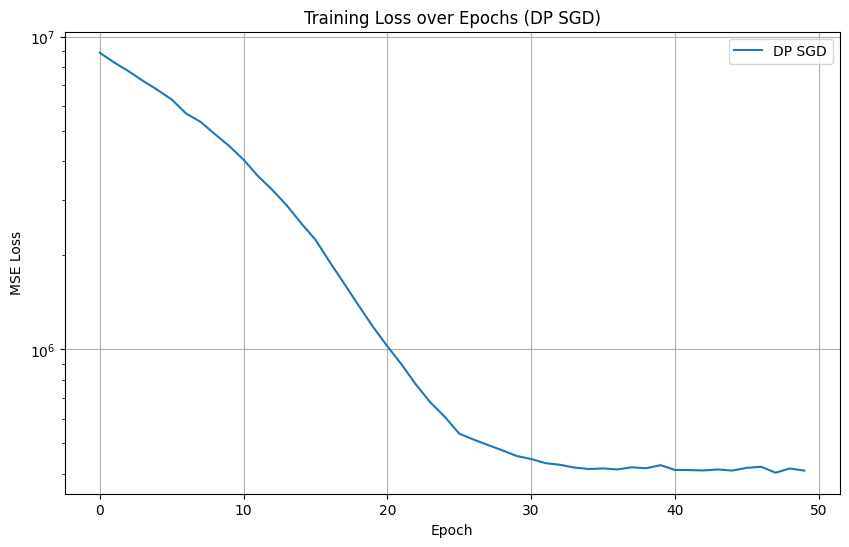

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(dp_losses, label='DP SGD')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Epochs (DP SGD)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Set y-axis to log scale
plt.show()

In [33]:
# --- Evaluate the DP Model on the Test Set ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dp.to(device)
model_dp.eval() # Set the model to evaluation mode

# Assuming X_test_tensor and y_test_tensor are available from feature_engineering

# Move test data to the device
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device).float()
y_test_tensor = y_test_tensor.unsqueeze(1) # Ensure target shape matches output shape

with torch.no_grad(): # Disable gradient calculation for evaluation
    predictions_dp = model_dp(X_test_tensor)
    test_loss_dp = criterion(predictions_dp, y_test_tensor)

print(f"\n--- DP Model Test Set Evaluation ---")
print(f"MSE Loss on Test Set: {test_loss_dp.item():.4f}")


--- DP Model Test Set Evaluation ---
MSE Loss on Test Set: 48671.5195
